# Menguji Keterbatasan YOLO pada Objek Kecil yang Berkelompok di VisDrone-DET

**Mata kuliah:** Computer Vision MKA  |  **Bentuk tugas:** Individu  |  **Topik:** Opsi C — YOLO

**Paper rujukan.** J. Redmon, S. Divvala, R. Girshick, A. Farhadi, "You Only Look Once: Unified, Real-Time Object Detection," *CVPR*, 2016.

**Klaim yang diuji (Bagian 2.4, *Limitations of YOLO*).** Paper menyatakan bahwa setiap sel grid hanya memprediksi dua kotak dan satu kelas, sehingga model kesulitan mendeteksi objek kecil yang muncul berkelompok. Paper juga menyatakan bahwa fungsi *loss* memperlakukan galat pada kotak kecil dan kotak besar secara sama.

**Pertanyaan riset.**
1. **RQ1 (struktural).** Berapa fraksi objek VisDrone yang kehilangan "sel penanggung jawab" pada formulasi YOLOv1 ($S=7$, satu objek per sel), dan bagaimana fraksi itu berubah pada grid yang lebih rapat?
2. **RQ2 (empiris).** Apakah YOLO modern (YOLO11) masih lebih lemah pada objek kecil dan pada citra yang padat? Pengujian memakai AP@0,5 dan AP@0,5:0,95 yang dirinci menurut ukuran objek (*small/medium/large*) dan tingkat kepadatan citra.
3. **RQ3 (intervensi).** Apakah menaikkan resolusi masukan dan *tiling* citra (irisan berukuran 640 piksel dengan tumpang tindih 20%) mengecilkan kesenjangan tersebut?

**Rancangan singkat.** Pengujian memakai tiga model, yaitu YOLO11n pralatih COCO (*zero-shot*), YOLO11s pralatih COCO (pembanding kapasitas model), dan YOLO11n hasil *fine-tuning* pada subset VisDrone-DET *train*. Setiap model dievaluasi pada seluruh 548 citra VisDrone-DET *val* dengan lima konfigurasi inferensi. Semua angka, tabel, dan grafik pada laporan dihasilkan oleh notebook ini.

## 0. Alur eksperimen

| Tahap | Isi | Kaitan dengan paper |
|---|---|---|
| 1 | Setup, seed, dan konfigurasi | — |
| 2 | Unduh data dan bobot secara otomatis | — |
| 3 | Statistik dataset (ukuran dan kepadatan objek) | Bagian 2.4 (objek kecil berkelompok) |
| 4 | Analisis struktural grid YOLOv1 | Bagian 2 (formulasi $S\times S$ sel, satu kelas per sel) |
| 5 | Sensitivitas IoU terhadap ukuran kotak dan resolusi efektif | Bagian 2.4 (galat kotak kecil vs besar) |
| 6 | Evaluator AP gaya COCO dan pengujian mandiri | Metrik wajib |
| 7 | Fungsi inferensi: resolusi masukan dan *tiling* | Intervensi |
| 8 | *Fine-tuning* YOLO11n pada VisDrone | — |
| 9 | Evaluasi seluruh konfigurasi | RQ2, RQ3 |
| 10 | Rincian menurut kepadatan citra | RQ2 |
| 11 | mAP per kelas (10 kelas) untuk model *fine-tuned* | Metrik wajib |
| 12 | Analisis kasus gagal (visual) | Analisis |
| 13 | Ringkasan dan penyimpanan hasil | — |

## 1. Setup, seed, dan konfigurasi

Sel berikut memasang paket yang belum tersedia, menetapkan seed, dan memilih profil komputasi. Profil `ringan` adalah konfigurasi yang dilaporkan. Profil ini dirancang agar dapat berjalan di CPU maupun GPU (Colab). Profil `uji` hanya dipakai untuk memeriksa bahwa alur notebook berjalan, dan tidak dipakai untuk melaporkan hasil.

In [ ]:
import importlib, os, subprocess, sys

# Mematikan bilah kemajuan dan log panjang Ultralytics agar keluaran notebook ringkas
os.environ['YOLO_VERBOSE'] = 'False'

def pastikan_paket(impor, pip_nama):
    try:
        importlib.import_module(impor)
    except ImportError:
        cmd = [sys.executable, '-m', 'pip', 'install', '-q', pip_nama]
        if os.environ.get('PIP_BREAK_SYSTEM') == '1':
            cmd.append('--break-system-packages')
        subprocess.check_call(cmd)

pastikan_paket('ultralytics', 'ultralytics')
pastikan_paket('pycocotools', 'pycocotools')
try:
    pastikan_paket('faster_coco_eval', 'faster-coco-eval')
except Exception:
    pass   # bila gagal, evaluator pycocotools asli dipakai (hasil sama, hanya lebih lambat)
print('Paket siap.')

Paket siap.


In [ ]:
import contextlib, glob, io, json, platform, random, shutil, time, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
try:
    from faster_coco_eval import COCOeval_faster as COCOeval   # implementasi C++ dengan hasil identik (selisih 0,0 pada uji)
except ImportError:
    pass
from torchvision.ops import nms
import ultralytics
from ultralytics import YOLO

# --- Seed untuk reproduktibilitas -------------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- Jalur penyimpanan -------------------------------------------------------------
DATA_ROOT = os.environ.get('DATA_ROOT', '/content/data')
HASIL = os.environ.get('HASIL_DIR', '/content/hasil')
CACHE = os.path.join(HASIL, 'cache')
for d in (DATA_ROOT, HASIL, CACHE):
    os.makedirs(d, exist_ok=True)

# --- Profil komputasi -----------------------------------------------------------------
PROFIL = os.environ.get('PROFIL', 'ringan')
KONFIG = {
    # Konfigurasi yang dilaporkan: subset latih 1000 citra, 12 epoch, seluruh 548 citra val.
    'ringan': dict(n_train=1000, n_hold=50, epoch=12, n_val=None, batch=8),
    # Hanya untuk memeriksa alur notebook.
    'uji':    dict(n_train=60,   n_hold=20, epoch=1,  n_val=40,   batch=8),
}[PROFIL]
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
plt.rcParams.update({'figure.dpi': 110, 'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
                     'legend.fontsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 7})

print('Profil       :', PROFIL, KONFIG)
print('Perangkat    :', 'GPU ' + torch.cuda.get_device_name(0) if DEVICE != 'cpu' else 'CPU', '| inti CPU:', os.cpu_count())
print('Perangkat lunak: Python', platform.python_version(), '| torch', torch.__version__, '| ultralytics', ultralytics.__version__)
print('DATA_ROOT    :', DATA_ROOT)

Profil       : ringan {'n_train': 1000, 'n_hold': 50, 'epoch': 12, 'n_val': None, 'batch': 8}
Perangkat    : GPU Tesla T4 | inti CPU: 2
Perangkat lunak: Python 3.13.15 | torch 2.11.0+cu130 | ultralytics 8.4.172
DATA_ROOT    : /content/data


## 2. Unduh data dan bobot secara otomatis

Dataset yang dipakai adalah **VisDrone-DET 2019** (Du et al., 2019), yaitu citra dari drone dengan sepuluh kategori objek (*pedestrian, people, bicycle, car, van, truck, tricycle, awning-tricycle, bus, motor*). Dataset ini berbeda dari dataset tutorial (Penn-Fudan), banyak memuat objek kecil, dan sering berkelompok.

Berkas diunduh dari rilis GitHub Ultralytics yang bersifat publik. Berkas *train* berukuran sekitar 1,5 GB, sehingga hanya subset citra terpilih (dipilih dengan seed tetap) yang diekstrak. Bobot YOLO11 pralatih COCO diunduh dari rilis yang sama.

Format anotasi VisDrone: `x, y, lebar, tinggi, skor, kategori, terpotong, terhalang`. Kategori 0 (wilayah yang diabaikan) dan 11 (*others*) bernilai skor 0. Anotasi ini diperlakukan sebagai **wilayah abaikan**, yaitu deteksi yang jatuh di dalamnya tidak dihitung sebagai *false positive*, mengikuti konvensi VisDrone.

In [ ]:
RILIS = 'https://github.com/ultralytics/assets/releases/download'
SUMBER = {
    'val':        f'{RILIS}/v0.0.0/VisDrone2019-DET-val.zip',
    'train':      f'{RILIS}/v0.0.0/VisDrone2019-DET-train.zip',
    'yolo11n.pt': f'{RILIS}/v8.3.0/yolo11n.pt',
    'yolo11s.pt': f'{RILIS}/v8.3.0/yolo11s.pt',
}
BERKAS = {'val': 'VisDrone2019-DET-val.zip', 'train': 'VisDrone2019-DET-train.zip',
          'yolo11n.pt': 'yolo11n.pt', 'yolo11s.pt': 'yolo11s.pt'}
UNDUH = os.path.join(DATA_ROOT, 'unduhan')
os.makedirs(UNDUH, exist_ok=True)

def unduh(kunci):
    tujuan = os.path.join(UNDUH, BERKAS[kunci])
    if not os.path.exists(tujuan):
        print('Mengunduh', SUMBER[kunci])
        urllib.request.urlretrieve(SUMBER[kunci], tujuan + '.part')
        os.rename(tujuan + '.part', tujuan)
    return tujuan

zip_val, zip_train = unduh('val'), unduh('train')
W_N, W_S = unduh('yolo11n.pt'), unduh('yolo11s.pt')

VD_DIR = os.path.join(DATA_ROOT, 'visdrone')
os.makedirs(VD_DIR, exist_ok=True)
if not os.path.isdir(os.path.join(VD_DIR, 'VisDrone2019-DET-val', 'images')):
    with zipfile.ZipFile(zip_val) as z:
        z.extractall(VD_DIR)

# Memilih subset train dengan seed tetap: n_train untuk pelatihan, n_hold untuk pemilihan checkpoint
rng_sub = np.random.default_rng(SEED)
with zipfile.ZipFile(zip_train) as z:
    semua = sorted({os.path.splitext(os.path.basename(n))[0] for n in z.namelist() if n.endswith('.jpg')})
    urut = rng_sub.permutation(len(semua))[:KONFIG['n_train'] + KONFIG['n_hold']]
    pilih = [semua[i] for i in urut]
    for n in pilih:
        for sub, ext in (('images', 'jpg'), ('annotations', 'txt')):
            tujuan = os.path.join(VD_DIR, 'VisDrone2019-DET-train', sub, f'{n}.{ext}')
            if not os.path.exists(tujuan):
                z.extract(f'VisDrone2019-DET-train/{sub}/{n}.{ext}', VD_DIR)
NAMA_LATIH, NAMA_HOLD = pilih[:KONFIG['n_train']], pilih[KONFIG['n_train']:]
print(f'Total citra train di arsip: {len(semua)} | dipakai latih: {len(NAMA_LATIH)} | hold-out: {len(NAMA_HOLD)}')
print('Citra val tersedia:', len(glob.glob(os.path.join(VD_DIR, 'VisDrone2019-DET-val', 'images', '*.jpg'))))

Mengunduh https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-val.zip
Mengunduh https://github.com/ultralytics/assets/releases/download/v0.0.0/VisDrone2019-DET-train.zip
Mengunduh https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt
Mengunduh https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11s.pt
Total citra train di arsip: 6471 | dipakai latih: 1000 | hold-out: 50
Citra val tersedia: 548


## 3. Memuat anotasi dan statistik dataset

Fungsi `baca_anotasi` memisahkan kotak valid (skor 1, kategori 1–10) dari wilayah abaikan (skor 0). Ukuran objek didefinisikan seperti pada COCO, yaitu *small* bila luas kotak $< 32^2$ piksel, *medium* bila $32^2 \le$ luas $< 96^2$, dan *large* bila luas $\ge 96^2$. Ukuran ini dihitung pada resolusi asli citra.

Set uji adalah seluruh VisDrone-DET *val* (548 citra). Subset *train* tidak beririsan dengan set uji.

,Citra,Objek valid,Median objek/citra,Maks objek/citra,Citra > 49 objek (%),Small (%),Medium (%),Large (%)
Himpunan,,,,,,,,
VisDrone-DET val (uji),548,38759,65.0,317,65.5,68.6,28.7,2.8
Subset train (latih),1000,52027,41.5,351,41.2,60.1,34.2,5.7


Kelas,pedestrian,people,bicycle,car,van,truck,tricycle,awning-tricycle,bus,motor
Val,8844,5125,1287,14064,1975,750,1045,532,251,4886
Subset train,12277,4018,1485,21956,3702,1964,783,552,778,4512


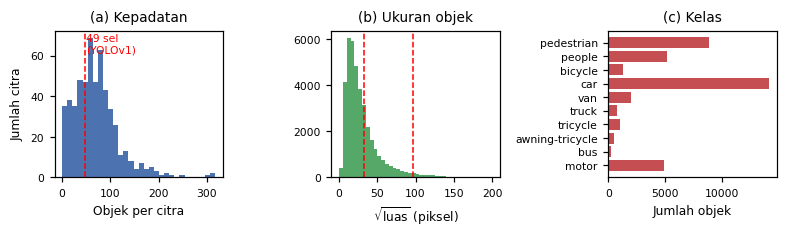

In [ ]:
KELAS = ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
COCO_DIPAKAI = [0, 1, 2, 3, 5, 7]   # kelas COCO yang berpadanan: person, bicycle, car, motorcycle, bus, truck

def baca_anotasi(path):
    """Mengembalikan (kotak valid xyxy, kelas 0..9, kotak abaikan xyxy)."""
    a = np.loadtxt(path, delimiter=',', ndmin=2)
    if a.size == 0:
        return np.zeros((0, 4)), np.zeros(0, int), np.zeros((0, 4))
    xyxy = np.c_[a[:, 0], a[:, 1], a[:, 0] + a[:, 2], a[:, 1] + a[:, 3]]
    valid = (a[:, 4] == 1) & (a[:, 5] >= 1) & (a[:, 5] <= 10) & (a[:, 2] > 0) & (a[:, 3] > 0)
    abaikan = (a[:, 4] == 0) & (a[:, 2] > 0) & (a[:, 3] > 0)
    return xyxy[valid], a[valid, 5].astype(int) - 1, xyxy[abaikan]

def muat_rekaman(direktori, nama_berkas=None, batas=None):
    paths = sorted(glob.glob(os.path.join(direktori, 'images', '*.jpg')))
    if nama_berkas is not None:
        paths = [os.path.join(direktori, 'images', n + '.jpg') for n in nama_berkas]
    if batas is not None:
        paths = paths[:batas]
    rek = []
    for i, p in enumerate(paths):
        n = os.path.splitext(os.path.basename(p))[0]
        W, H = Image.open(p).size
        b, c, ig = baca_anotasi(os.path.join(direktori, 'annotations', n + '.txt'))
        rek.append(dict(id=i, nama=n, path=p, W=W, H=H, boxes=b, cls=c, ign=ig))
    return rek

DIR_VAL = os.path.join(VD_DIR, 'VisDrone2019-DET-val')
DIR_TRAIN = os.path.join(VD_DIR, 'VisDrone2019-DET-train')
REK_VAL = muat_rekaman(DIR_VAL, batas=KONFIG['n_val'])
REK_LATIH = muat_rekaman(DIR_TRAIN, NAMA_LATIH)
REK_HOLD = muat_rekaman(DIR_TRAIN, NAMA_HOLD)

def ringkas(rek, nama):
    n_obj = np.array([len(r['boxes']) for r in rek])
    sisi = np.concatenate([np.sqrt((r['boxes'][:, 2] - r['boxes'][:, 0]) * (r['boxes'][:, 3] - r['boxes'][:, 1])) for r in rek if len(r['boxes'])])
    return {'Himpunan': nama, 'Citra': len(rek), 'Objek valid': int(n_obj.sum()),
            'Median objek/citra': float(np.median(n_obj)), 'Maks objek/citra': int(n_obj.max()),
            'Citra > 49 objek (%)': 100 * float((n_obj > 49).mean()),
            'Small (%)': 100 * float((sisi < 32).mean()),
            'Medium (%)': 100 * float(((sisi >= 32) & (sisi < 96)).mean()),
            'Large (%)': 100 * float((sisi >= 96).mean())}

tabel_data = pd.DataFrame([ringkas(REK_VAL, 'VisDrone-DET val (uji)'), ringkas(REK_LATIH, 'Subset train (latih)')]).set_index('Himpunan')
display(tabel_data.round(1))

hitung_kelas = pd.DataFrame({'Kelas': KELAS,
    'Val': [int(sum((r['cls'] == k).sum() for r in REK_VAL)) for k in range(10)],
    'Subset train': [int(sum((r['cls'] == k).sum() for r in REK_LATIH)) for k in range(10)]}).set_index('Kelas')
display(hitung_kelas.T)

fig, ax = plt.subplots(1, 3, figsize=(7.2, 2.2))
n_obj_val = np.array([len(r['boxes']) for r in REK_VAL])
ax[0].hist(n_obj_val, bins=30, color='#4c72b0'); ax[0].axvline(49, color='r', ls='--', lw=1)
ax[0].text(51, ax[0].get_ylim()[1] * 0.85, '49 sel\n(YOLOv1)', color='r', fontsize=7)
ax[0].set_xlabel('Objek per citra'); ax[0].set_ylabel('Jumlah citra'); ax[0].set_title('(a) Kepadatan')
sisi_val = np.concatenate([np.sqrt((r['boxes'][:, 2] - r['boxes'][:, 0]) * (r['boxes'][:, 3] - r['boxes'][:, 1])) for r in REK_VAL])
ax[1].hist(sisi_val, bins=np.linspace(0, 200, 41), color='#55a868')
for v in (32, 96): ax[1].axvline(v, color='r', ls='--', lw=1)
ax[1].set_xlabel(r'$\sqrt{\mathrm{luas}}$ (piksel)'); ax[1].set_title('(b) Ukuran objek')
ax[2].barh(KELAS, hitung_kelas['Val'], color='#c44e52'); ax[2].invert_yaxis(); ax[2].set_xlabel('Jumlah objek'); ax[2].set_title('(c) Kelas')
plt.tight_layout(); plt.savefig(os.path.join(HASIL, 'g1_statistik.png'), dpi=220, bbox_inches='tight'); plt.show()

## 4. RQ1: Analisis struktural grid YOLOv1

**Formulasi paper.** YOLOv1 membagi citra menjadi grid $S\times S$. Sel yang memuat titik pusat objek bertanggung jawab memprediksi objek tersebut. Parameterisasi targetnya ialah

$$x = c_x S - \text{kolom},\quad y = c_y S - \text{baris},\quad w, h \text{ relatif terhadap citra},$$

dengan $(c_x, c_y)$ pusat kotak ternormalisasi. Setiap sel membawa satu set probabilitas kelas, sehingga hanya satu objek yang dapat ditetapkan per sel. Bila dua pusat objek jatuh di sel yang sama, target hanya memuat satu objek.

Fungsi `encode_yolov1_target` di bawah mengimplementasikan penetapan target tersebut. Objek yang tidak memperoleh sel (karena sudah ditempati) menjadi **kehilangan struktural**. Fraksi retensi menjadi **batas atas recall** bagi detektor yang dilatih dengan target seperti ini, apa pun kualitas jaringannya.

Analisis ini tidak memerlukan model dan dijalankan pada seluruh citra *val*. Nilai $S=7$ adalah konfigurasi paper. Nilai lain mewakili grid yang lebih rapat, yaitu stride 32, 16, dan 8 pada masukan 640 piksel ($S=20, 40, 80$), serta stride 8 pada masukan 1280 piksel ($S=160$). Pada detektor modern yang tidak memakai anchor (YOLO11), penetapan target bersifat banyak-ke-satu per sel dan multi-skala, sehingga batas satu objek per sel tidak berlaku. Karena itu hasil untuk $S>7$ hanya menunjukkan **seberapa ketat** batas itu bila diterapkan pada grid rapat.

,Keterangan,Sel,Objek diretensi (%),Kehilangan (%)
S,,,,
7,YOLOv1 (paper),49,26.0,74.0
13,stride 32 @ ~416,169,45.0,55.0
20,stride 32 @ 640,400,59.7,40.3
40,stride 16 @ 640,1600,79.6,20.4
80,stride 8 @ 640,6400,92.2,7.8
160,stride 8 @ 1280,25600,98.0,2.0


Objek valid total: 38759 | median objek/citra: 65 | kapasitas YOLOv1: 49 objek/citra
Citra yang melebihi 49 objek: 359 dari 548 (65.5%)


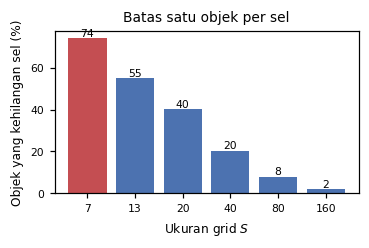

In [ ]:
def encode_yolov1_target(boxes, W, H, S=7, C=1, kelas=None):
    """Target YOLOv1 (S, S, 5 + C): [x, y, w, h, objek, kelas...]. Satu objek per sel."""
    T = np.zeros((S, S, 5 + C), np.float32)
    kelas = np.zeros(len(boxes), int) if kelas is None else kelas
    for (x1, y1, x2, y2), c in zip(boxes, kelas):
        cx, cy = (x1 + x2) / 2 / W, (y1 + y2) / 2 / H
        bw, bh = (x2 - x1) / W, (y2 - y1) / H
        col, row = min(int(cx * S), S - 1), min(int(cy * S), S - 1)
        if T[row, col, 4] == 1:          # sel sudah ditempati: objek ini hilang
            continue
        T[row, col, :5] = [cx * S - col, cy * S - row, bw, bh, 1.0]
        T[row, col, 5 + (int(c) if C > 1 else 0)] = 1.0
    return T

def retensi_grid(rek, S):
    total = ditetapkan = 0
    for r in rek:
        if len(r['boxes']) == 0:
            continue
        T = encode_yolov1_target(r['boxes'], r['W'], r['H'], S=S)
        total += len(r['boxes']); ditetapkan += int(T[..., 4].sum())
    return ditetapkan / max(total, 1), total

# Pemeriksaan mandiri: contoh sintetis dengan dua objek di sel yang sama
T_uji = encode_yolov1_target(np.array([[10, 10, 20, 20], [12, 12, 22, 22]], float), 700, 700, S=7)
assert T_uji[..., 4].sum() == 1, 'Dua pusat dalam satu sel harus menyisakan satu objek'

barisan = []
for S, ket in [(7, 'YOLOv1 (paper)'), (13, 'stride 32 @ ~416'), (20, 'stride 32 @ 640'), (40, 'stride 16 @ 640'),
               (80, 'stride 8 @ 640'), (160, 'stride 8 @ 1280')]:
    frak, total = retensi_grid(REK_VAL, S)
    barisan.append({'S': S, 'Keterangan': ket, 'Sel': S * S, 'Objek diretensi (%)': 100 * frak, 'Kehilangan (%)': 100 * (1 - frak)})
tabel_grid = pd.DataFrame(barisan).set_index('S')
display(tabel_grid.round(1))
print(f'Objek valid total: {total} | median objek/citra: {np.median(n_obj_val):.0f} | kapasitas YOLOv1: 49 objek/citra')
print(f'Citra yang melebihi 49 objek: {(n_obj_val > 49).sum()} dari {len(n_obj_val)} ({100 * (n_obj_val > 49).mean():.1f}%)')

fig, ax = plt.subplots(figsize=(3.4, 2.3))
ax.bar([str(s) for s in tabel_grid.index], tabel_grid['Kehilangan (%)'], color=['#c44e52'] + ['#4c72b0'] * 5)
for i, v in enumerate(tabel_grid['Kehilangan (%)']):
    ax.text(i, v + 1, f'{v:.0f}', ha='center', fontsize=7)
ax.set_xlabel('Ukuran grid $S$'); ax.set_ylabel('Objek yang kehilangan sel (%)')
ax.set_title('Batas satu objek per sel')
plt.tight_layout(); plt.savefig(os.path.join(HASIL, 'g2_grid.png'), dpi=220, bbox_inches='tight'); plt.show()

## 5. Sensitivitas IoU terhadap ukuran kotak dan resolusi efektif

Paper menyatakan bahwa *loss* memperlakukan galat yang sama pada kotak kecil dan besar, padahal galat kecil pada kotak kecil lebih merusak IoU. Sel berikut mengukur hal tersebut. Dua analisis dilakukan.

1. **Sensitivitas IoU.** Sebuah kotak persegi dengan sisi $s$ digeser sejauh $\delta$ piksel. IoU yang tersisa menunjukkan betapa presisi lokalisasi yang dituntut bergantung pada ukuran objek.
2. **Resolusi efektif.** Citra VisDrone berukuran sekitar $1360\times765$ piksel. Pada masukan 640 piksel, citra diperkecil sekitar $0{,}47\times$. Sel berikut menghitung fraksi objek yang sisinya lebih kecil daripada stride terhalus detektor (8 piksel) dan stride menengah (16 piksel) setelah penskalaan.

In [ ]:
def iou_geser(sisi, delta):
    irisan = max(sisi - delta, 0) * sisi
    return irisan / (2 * sisi ** 2 - irisan)

tabel_iou = pd.DataFrame({'Sisi kotak (px)': [8, 16, 32, 64, 128],
                          'IoU, geser 2 px': [iou_geser(s, 2) for s in [8, 16, 32, 64, 128]],
                          'IoU, geser 4 px': [iou_geser(s, 4) for s in [8, 16, 32, 64, 128]]}).set_index('Sisi kotak (px)')
display(tabel_iou.round(3))

def fraksi_di_bawah_stride(rek, skala_fn):
    sisi, skala = [], []
    for r in rek:
        if len(r['boxes']) == 0:
            continue
        s = np.sqrt((r['boxes'][:, 2] - r['boxes'][:, 0]) * (r['boxes'][:, 3] - r['boxes'][:, 1]))
        sisi.append(s * skala_fn(r))
    sisi = np.concatenate(sisi)
    return {'Median sisi (px)': float(np.median(sisi)), '< 8 px (%)': 100 * float((sisi < 8).mean()),
            '< 16 px (%)': 100 * float((sisi < 16).mean())}

baris = []
for nama, fn in [('Masukan 640', lambda r: 640 / max(r['W'], r['H'])), ('Masukan 960', lambda r: 960 / max(r['W'], r['H'])),
                 ('Masukan 1280', lambda r: 1280 / max(r['W'], r['H'])), ('Tiling (resolusi asli)', lambda r: 1.0)]:
    baris.append({'Konfigurasi': nama, **fraksi_di_bawah_stride(REK_VAL, fn)})
tabel_resolusi = pd.DataFrame(baris).set_index('Konfigurasi')
display(tabel_resolusi.round(1))

,"IoU, geser 2 px","IoU, geser 4 px"
Sisi kotak (px),,
8,0.600,0.333
16,0.778,0.600
32,0.882,0.778
64,0.939,0.882
128,0.969,0.939


,Median sisi (px),< 8 px (%),< 16 px (%)
Konfigurasi,,,
Masukan 640,11.3,30.8,69.9
Masukan 960,16.9,13.3,46.9
Masukan 1280,22.5,5.7,30.8
Tiling (resolusi asli),22.8,6.0,30.8


## 6. Evaluator AP gaya COCO dan pengujian mandiri

Evaluasi memakai `pycocotools` (atau `faster-coco-eval`, implementasi C++ dengan antarmuka dan hasil identik; pada uji, selisih AP terbesar 0,0) dengan pengaturan yang disesuaikan untuk kepadatan VisDrone.

- **`maxDets = 500`.** Pengaturan bawaan COCO (100 deteksi per citra) akan memotong recall pada citra padat, padahal citra *val* memuat hingga 317 objek. Karena itu batas dinaikkan menjadi 500.
- **Wilayah abaikan** (skor 0) dimasukkan sebagai anotasi `iscrowd=1`, sehingga deteksi di dalamnya tidak dihitung sebagai *false positive*.
- **Rincian ukuran** memakai rentang luas COCO ($32^2$ dan $96^2$ piksel) pada resolusi asli citra.
- **Dua mode.** Mode *agnostik kelas* menggabungkan seluruh kelas menjadi satu kategori objek. Mode ini adil bagi model *zero-shot* COCO yang tidak mengenal kelas khusus VisDrone, dan memusatkan pengujian pada lokalisasi dan kepadatan. Mode *sadar kelas* (10 kelas) dipakai untuk model *fine-tuned*.
- **Pengujian mandiri.** Bila GT dijadikan deteksi, AP harus bernilai 1 (dengan toleransi 0,001, karena kotak GT yang bertumpang tindih rapat menyebabkan penyimpangan sangat kecil pada urutan pencocokan seri).

In [ ]:
def bangun_gt_coco(rek, sadar_kelas=False):
    ncat = len(KELAS) if sadar_kelas else 1
    d = {'images': [], 'annotations': [], 'categories': [{'id': k + 1, 'name': str(k)} for k in range(ncat)]}
    aid = 1
    for r in rek:
        d['images'].append({'id': r['id'], 'width': r['W'], 'height': r['H']})
        for b, c in zip(r['boxes'], r['cls']):
            w, h = b[2] - b[0], b[3] - b[1]
            d['annotations'].append({'id': aid, 'image_id': r['id'], 'category_id': int(c) + 1 if sadar_kelas else 1,
                                     'bbox': [float(b[0]), float(b[1]), float(w), float(h)], 'area': float(w * h), 'iscrowd': 0}); aid += 1
        for b in r['ign']:
            w, h = b[2] - b[0], b[3] - b[1]
            for k in range(ncat):
                d['annotations'].append({'id': aid, 'image_id': r['id'], 'category_id': k + 1,
                                         'bbox': [float(b[0]), float(b[1]), float(w), float(h)], 'area': float(w * h), 'iscrowd': 1}); aid += 1
    coco = COCO(); coco.dataset = d
    with contextlib.redirect_stdout(io.StringIO()):
        coco.createIndex()
    return coco

UKURAN = ['semua', 'kecil', 'sedang', 'besar']

def evaluasi_coco(coco_gt, deteksi, img_ids=None, sadar_kelas=False):
    """deteksi: array (N, 7) = [id_citra, kelas, skor, x1, y1, x2, y2]."""
    ids = list(coco_gt.getImgIds()) if img_ids is None else list(img_ids)
    if len(deteksi) == 0:
        return {f'{m}_{n}': 0.0 for m in ('AP50', 'AP50:95', 'AR50') for n in UKURAN}
    dl = [{'image_id': int(i), 'category_id': int(c) + 1 if sadar_kelas else 1, 'score': float(s),
           'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]} for i, c, s, x1, y1, x2, y2 in deteksi]
    with contextlib.redirect_stdout(io.StringIO()):
        dt = coco_gt.loadRes(dl)
        E = COCOeval(coco_gt, dt, 'bbox')
        E.params.imgIds = ids
        E.params.maxDets = [10, 100, 500]
        E.evaluate(); E.accumulate()
    P, R = E.eval['precision'], E.eval['recall']           # [T,R,K,A,M], [T,K,A,M]
    def rata(x):
        x = x[x > -1]
        return float(x.mean()) if x.size else float('nan')
    out = {}
    for a, n in enumerate(UKURAN):
        out[f'AP50_{n}'] = rata(P[0, :, :, a, 2])
        out[f'AP50:95_{n}'] = rata(P[:, :, :, a, 2])
        out[f'AR50_{n}'] = rata(R[0, :, a, 2])
    return out

GT_AGNOSTIK = bangun_gt_coco(REK_VAL, sadar_kelas=False)
GT_KELAS = bangun_gt_coco(REK_VAL, sadar_kelas=True)

# Pengujian mandiri: GT sebagai deteksi harus menghasilkan AP = 1
det_gt = np.array([[r['id'], 0, 1.0, *b] for r in REK_VAL for b in r['boxes']])
cek = evaluasi_coco(GT_AGNOSTIK, det_gt)
print('Pengujian mandiri (GT sebagai deteksi):', {k: round(v, 3) for k, v in cek.items() if k.startswith('AP50_')})
# Toleransi 1e-3: satu kotak GT kembar identik dan sekitar 1.900 objek yang bertumpang tindih rapat (IoU >= 0,5)
# membuat urutan pencocokan seri menyimpang tipis (< 1e-4) dari nilai ideal 1.
print('Selisih terbesar dari 1,0:', max(abs(cek[f'AP50_{n}'] - 1.0) for n in UKURAN))
assert all(abs(cek[f'AP50_{n}'] - 1.0) < 1e-3 for n in UKURAN), 'Evaluator tidak lolos pengujian mandiri'

Pengujian mandiri (GT sebagai deteksi): {'AP50_semua': 1.0, 'AP50_kecil': 1.0, 'AP50_sedang': 1.0, 'AP50_besar': 1.0}
Selisih terbesar dari 1,0: 6.589973622272982e-05


## 7. Fungsi inferensi: resolusi masukan dan *tiling*

Lima konfigurasi inferensi dibandingkan.

| Konfigurasi | Penjelasan |
|---|---|
| `640`, `960`, `1280` | Seluruh citra diperkecil sehingga sisi terpanjangnya sama dengan nilai tersebut (kebijakan *letterbox* Ultralytics). |
| `tiling` | Citra dipotong menjadi irisan 640×640 piksel dengan tumpang tindih 20% pada resolusi asli. Deteksi tiap irisan digabung dengan NMS global (IoU 0,5). |
| `tiling+penuh` | Sama dengan `tiling`, ditambah satu inferensi seluruh citra pada masukan 640 piksel. Cara ini membantu objek besar yang terpotong irisan. |

Seluruh inferensi memakai ambang kepercayaan 0,001 (agar kurva PR lengkap), NMS dalam-irisan IoU 0,7, dan maksimum 500 deteksi. NMS bersifat agnostik kelas. Teknik *tiling* ini disederhanakan dari SAHI (Akyon et al., 2022): penggabungan memakai NMS biasa, bukan *greedy NMM*.

In [ ]:
def prediksi_penuh(model, sumber, imgsz, kelas=None, conf=0.001, iou=0.7, max_det=500):
    r = model.predict(sumber, imgsz=imgsz, conf=conf, iou=iou, max_det=max_det, classes=kelas,
                      agnostic_nms=True, device=DEVICE, verbose=False)[0]
    return r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy(), r.boxes.cls.cpu().numpy().astype(int)

def posisi_tile(W, H, tile=640, overlap=0.2):
    langkah = max(int(tile * (1 - overlap)), 1)
    def sumbu(n):
        if n <= tile:
            return [0]
        p = list(range(0, n - tile + 1, langkah))
        if p[-1] != n - tile:
            p.append(n - tile)
        return p
    return [(x, y) for y in sumbu(H) for x in sumbu(W)]

def prediksi_tiling(model, path, dengan_penuh=False, tile=640, overlap=0.2, kelas=None,
                    conf=0.001, iou_nms=0.7, iou_gabung=0.5, max_det=500):
    # Ultralytics menganggap larik NumPy berformat BGR (konvensi OpenCV), sehingga kanal dibalik
    img = np.ascontiguousarray(np.array(Image.open(path).convert('RGB'))[..., ::-1])
    H, W = img.shape[:2]
    B, S, C = [], [], []
    for x, y in posisi_tile(W, H, tile, overlap):
        r = model.predict(img[y:y + tile, x:x + tile], imgsz=tile, conf=conf, iou=iou_nms, max_det=max_det,
                          classes=kelas, agnostic_nms=True, device=DEVICE, verbose=False)[0]
        b = r.boxes.xyxy.cpu().numpy().copy()
        if len(b):
            b[:, [0, 2]] += x; b[:, [1, 3]] += y
            B.append(b); S.append(r.boxes.conf.cpu().numpy()); C.append(r.boxes.cls.cpu().numpy().astype(int))
    if dengan_penuh:
        b, s, c = prediksi_penuh(model, path, 640, kelas, conf, iou_nms, max_det)
        if len(b):
            B.append(b); S.append(s); C.append(c)
    if not B:
        return np.zeros((0, 4)), np.zeros(0), np.zeros(0, int)
    B, S, C = np.concatenate(B), np.concatenate(S), np.concatenate(C)
    keep = nms(torch.from_numpy(B).float(), torch.from_numpy(S).float(), iou_gabung).numpy()[:max_det]
    return B[keep], S[keep], C[keep]

KONFIG_INFERENSI = {
    '640':          lambda m, p, k: prediksi_penuh(m, p, 640, k),
    '960':          lambda m, p, k: prediksi_penuh(m, p, 960, k),
    '1280':         lambda m, p, k: prediksi_penuh(m, p, 1280, k),
    'tiling':       lambda m, p, k: prediksi_tiling(m, p, False, kelas=k),
    'tiling+penuh': lambda m, p, k: prediksi_tiling(m, p, True, kelas=k),
}

print('Jumlah irisan 640 (tumpang tindih 20%) untuk citra 1360x765:', len(posisi_tile(1360, 765)))
print('Jumlah irisan 640 untuk citra 1920x1080:', len(posisi_tile(1920, 1080)))

Jumlah irisan 640 (tumpang tindih 20%) untuk citra 1360x765: 6
Jumlah irisan 640 untuk citra 1920x1080: 8


## 8. *Fine-tuning* YOLO11n pada VisDrone

Model YOLO11n pralatih COCO dilatih lanjut pada subset VisDrone-DET *train*. Anotasi dikonversi ke format YOLO (`kelas x_pusat y_pusat lebar tinggi`, relatif terhadap citra). Format ini identik dengan parameterisasi target YOLOv1, kecuali bahwa pusat dinyatakan relatif terhadap citra dan bukan terhadap sel.

**Pengaturan.** Masukan pelatihan 640 piksel, ukuran *batch* 8, dan jumlah epoch sesuai profil. Parameter `nbs` disamakan dengan ukuran *batch* agar bobot diperbarui pada setiap iterasi, karena nilai bawaan (64) hanya memperbarui bobot setiap 8 iterasi dan terlalu jarang untuk subset kecil. Mosaik dimatikan pada dua epoch terakhir (`close_mosaic=2`). Pemilihan *checkpoint* memakai citra *hold-out* yang diambil dari *train*, sehingga **set uji tidak disentuh selama pelatihan**.

**Keterbatasan yang disadari.** Pelatihan singkat pada subset kecil menghasilkan model yang jauh dari konvergen. Hasilnya cukup untuk membandingkan konfigurasi inferensi pada model yang sama, tetapi tidak mewakili kemampuan penuh YOLO11 pada VisDrone.

In [ ]:
YOLO_DIR = os.path.join(DATA_ROOT, 'visdrone_yolo')
shutil.rmtree(YOLO_DIR, ignore_errors=True)

def tulis_himpunan(rek, nama):
    os.makedirs(os.path.join(YOLO_DIR, 'images', nama)); os.makedirs(os.path.join(YOLO_DIR, 'labels', nama))
    for r in rek:
        shutil.copy(r['path'], os.path.join(YOLO_DIR, 'images', nama, r['nama'] + '.jpg'))
        baris = [f"{int(c)} {(b[0] + b[2]) / 2 / r['W']:.6f} {(b[1] + b[3]) / 2 / r['H']:.6f} "
                 f"{(b[2] - b[0]) / r['W']:.6f} {(b[3] - b[1]) / r['H']:.6f}" for b, c in zip(r['boxes'], r['cls'])]
        with open(os.path.join(YOLO_DIR, 'labels', nama, r['nama'] + '.txt'), 'w') as f:
            f.write('\n'.join(baris))

tulis_himpunan(REK_LATIH, 'train'); tulis_himpunan(REK_HOLD, 'val')
with open(os.path.join(YOLO_DIR, 'data.yaml'), 'w') as f:
    f.write(f'path: {YOLO_DIR}\ntrain: images/train\nval: images/val\nnames:\n' + ''.join(f'  {i}: {n}\n' for i, n in enumerate(KELAS)))
print(open(os.path.join(YOLO_DIR, 'data.yaml')).read())
contoh = REK_LATIH[0]['nama']
print('Contoh label', contoh, ':\n' + open(os.path.join(YOLO_DIR, 'labels', 'train', contoh + '.txt')).read().split('\n')[0])

path: /content/data/visdrone_yolo
train: images/train
val: images/val
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor

Contoh label 9999982_00000_d_0000010 :
3 0.246786 0.541905 0.033571 0.020952


Waktu pelatihan: 104.6 menit pada CPU
Total waktu pelatihan tercatat di results.csv: 104.4 menit untuk 12 epoch (CPU).


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/mAP50(B),metrics/mAP50-95(B)
0,1,2.1104,3.7346,1.0951,0.0470,0.0221
1,2,2.1102,2.1392,1.0491,0.0844,0.0416
2,3,2.0163,1.8813,1.0399,0.0724,0.0328
3,4,1.9860,1.7968,1.0211,0.0915,0.0465
4,5,1.9448,1.7005,1.0058,0.1060,0.0550
5,6,1.8888,1.6165,0.9918,0.1348,0.0686
6,7,1.8926,1.6025,0.9835,0.1343,0.0694
7,8,1.8265,1.5268,0.9705,0.1471,0.0766
8,9,1.8069,1.5125,0.9636,0.1600,0.0855
9,10,1.7723,1.4627,0.9622,0.1640,0.0871


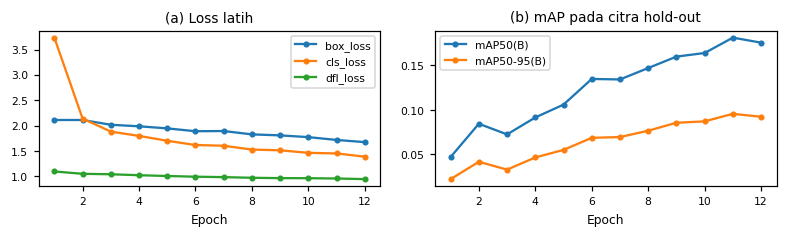

In [ ]:
RUN_DIR = os.path.join(HASIL, 'runs')
BOBOT_FT = os.path.join(RUN_DIR, 'visdrone_ft', 'weights', 'best.pt')

if os.path.exists(BOBOT_FT):
    print('Bobot fine-tuned ditemukan, pelatihan dilewati:', BOBOT_FT)
else:
    t0 = time.time()
    model_latih = YOLO(W_N)
    model_latih.train(data=os.path.join(YOLO_DIR, 'data.yaml'), epochs=KONFIG['epoch'], imgsz=640, batch=KONFIG['batch'],
                      seed=SEED, deterministic=True, device=DEVICE, workers=2, project=RUN_DIR, name='visdrone_ft',
                      exist_ok=True, plots=False, verbose=False, close_mosaic=min(2, KONFIG['epoch']), patience=100,
                      nbs=KONFIG['batch'])   # bobot diperbarui pada setiap iterasi (bawaan nbs=64 mengakumulasi gradien)
    WAKTU_LATIH = time.time() - t0
    print(f'Waktu pelatihan: {WAKTU_LATIH / 60:.1f} menit pada', 'GPU' if DEVICE != 'cpu' else 'CPU')

log = pd.read_csv(os.path.join(RUN_DIR, 'visdrone_ft', 'results.csv'))
log.columns = [c.strip() for c in log.columns]
if 'time' in log:
    print(f"Total waktu pelatihan tercatat di results.csv: {log['time'].iloc[-1] / 60:.1f} menit untuk {len(log)} epoch ({'GPU' if DEVICE != 'cpu' else 'CPU'}).")
kolom = [c for c in ['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)'] if c in log]
display(log[kolom].round(4))

fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.2))
for c in ['train/box_loss', 'train/cls_loss', 'train/dfl_loss']:
    ax[0].plot(log['epoch'], log[c], marker='o', ms=3, label=c.split('/')[1])
ax[0].set_xlabel('Epoch'); ax[0].set_title('(a) Loss latih'); ax[0].legend()
for c in ['metrics/mAP50(B)', 'metrics/mAP50-95(B)']:
    ax[1].plot(log['epoch'], log[c], marker='o', ms=3, label=c.split('/')[1])
ax[1].set_xlabel('Epoch'); ax[1].set_title('(b) mAP pada citra hold-out'); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(HASIL, 'g3_pelatihan.png'), dpi=220, bbox_inches='tight'); plt.show()

## 9. Evaluasi seluruh konfigurasi

Setiap pasangan (model, konfigurasi inferensi) dijalankan pada seluruh citra uji. Hasil deteksi disimpan di `cache/` sehingga pengulangan sel ini tidak menghitung ulang bila berkasnya ada. Pada *runtime* Colab yang baru, seluruh perhitungan dijalankan dari awal.

Daftar model dan konfigurasi:
- **YOLO11n zero-shot** dan **YOLO11n fine-tuned**: kelima konfigurasi.
- **YOLO11s zero-shot** (pembanding kapasitas model): konfigurasi `640`, `1280`, dan `tiling`. Konfigurasi dikurangi karena model ini lebih lambat di CPU.

Model *zero-shot* hanya memakai kelas COCO yang berpadanan (*person, bicycle, car, motorcycle, bus, truck*). Waktu per citra dihitung dari pemanggilan inferensi dan sudah termasuk pembacaan berkas citra.

In [ ]:
MODEL = {
    'YOLO11n zero-shot':    dict(bobot=W_N, kelas=COCO_DIPAKAI, konfig=['640', '960', '1280', 'tiling', 'tiling+penuh']),
    'YOLO11s zero-shot':    dict(bobot=W_S, kelas=COCO_DIPAKAI, konfig=['640', '1280', 'tiling']),
    'YOLO11n fine-tuned':   dict(bobot=BOBOT_FT, kelas=None,    konfig=['640', '960', '1280', 'tiling', 'tiling+penuh']),
}

def jalankan(nama_model, nama_konfig):
    berkas = os.path.join(CACHE, f"{PROFIL}__{nama_model.replace(' ', '_')}__{nama_konfig.replace('+', '_')}.npz")
    if os.path.exists(berkas):
        z = np.load(berkas)
        return z['det'], float(z['ms'])
    spes = MODEL[nama_model]
    model = YOLO(spes['bobot'])
    prediksi_penuh(model, REK_VAL[0]['path'], 640, spes['kelas'])      # pemanasan
    det, waktu = [], []
    for i, r in enumerate(REK_VAL):
        t0 = time.perf_counter()
        b, s, c = KONFIG_INFERENSI[nama_konfig](model, r['path'], spes['kelas'])
        waktu.append(time.perf_counter() - t0)
        if len(b):
            det.append(np.c_[np.full(len(b), r['id']), c, s, b])
        if (i + 1) % 100 == 0 or i + 1 == len(REK_VAL):
            print(f'  {nama_model} | {nama_konfig}: {i + 1}/{len(REK_VAL)} citra')
    det = np.concatenate(det) if det else np.zeros((0, 7))
    ms = 1000 * float(np.mean(waktu))
    np.savez(berkas, det=det, ms=ms)
    return det, ms

DETEKSI, MS = {}, {}
t_mulai = time.time()
for nm, spes in MODEL.items():
    for kf in spes['konfig']:
        DETEKSI[(nm, kf)], MS[(nm, kf)] = jalankan(nm, kf)
print(f'Seluruh inferensi selesai dalam {(time.time() - t_mulai) / 60:.1f} menit (menit nol bila memakai cache).')

  YOLO11n zero-shot | 640: 100/548 citra
  YOLO11n zero-shot | 640: 200/548 citra
  YOLO11n zero-shot | 640: 300/548 citra
  YOLO11n zero-shot | 640: 400/548 citra
  YOLO11n zero-shot | 640: 500/548 citra
  YOLO11n zero-shot | 640: 548/548 citra
  YOLO11n zero-shot | 960: 100/548 citra
  YOLO11n zero-shot | 960: 200/548 citra
  YOLO11n zero-shot | 960: 300/548 citra
  YOLO11n zero-shot | 960: 400/548 citra
  YOLO11n zero-shot | 960: 500/548 citra
  YOLO11n zero-shot | 960: 548/548 citra
  YOLO11n zero-shot | 1280: 100/548 citra
  YOLO11n zero-shot | 1280: 200/548 citra
  YOLO11n zero-shot | 1280: 300/548 citra
  YOLO11n zero-shot | 1280: 400/548 citra
  YOLO11n zero-shot | 1280: 500/548 citra
  YOLO11n zero-shot | 1280: 548/548 citra
  YOLO11n zero-shot | tiling: 100/548 citra
  YOLO11n zero-shot | tiling: 200/548 citra
  YOLO11n zero-shot | tiling: 300/548 citra
  YOLO11n zero-shot | tiling: 400/548 citra
  YOLO11n zero-shot | tiling: 500/548 citra
  YOLO11n zero-shot | tiling: 548/54

In [ ]:
baris = []
for (nm, kf), det in DETEKSI.items():
    h = evaluasi_coco(GT_AGNOSTIK, det)
    baris.append({'Model': nm, 'Konfigurasi': kf, **{k: v for k, v in h.items()}, 'ms/citra': MS[(nm, kf)], 'Deteksi/citra': len(det) / len(REK_VAL)})
HASIL_UTAMA = pd.DataFrame(baris)

kolom_ap50 = ['Model', 'Konfigurasi', 'AP50_semua', 'AP50_kecil', 'AP50_sedang', 'AP50_besar', 'ms/citra']
kolom_ap5095 = ['Model', 'Konfigurasi', 'AP50:95_semua', 'AP50:95_kecil', 'AP50:95_sedang', 'AP50:95_besar', 'AR50_kecil']
print('AP@0,5 menurut ukuran objek (mode agnostik kelas)')
display(HASIL_UTAMA[kolom_ap50].round(3).set_index(['Model', 'Konfigurasi']))
print('AP@0,5:0,95 menurut ukuran objek (mode agnostik kelas) dan recall@0,5 objek kecil')
display(HASIL_UTAMA[kolom_ap5095].round(3).set_index(['Model', 'Konfigurasi']))

AP@0,5 menurut ukuran objek (mode agnostik kelas)


AP50_semua  AP50_kecil  AP50_sedang  \
Model              Konfigurasi                                         
YOLO11n zero-shot  640                0.304       0.171        0.583   
                   960                0.418       0.288        0.679   
                   1280               0.488       0.362        0.728   
                   tiling             0.464       0.341        0.696   
                   tiling+penuh       0.457       0.336        0.690   
YOLO11s zero-shot  640                0.397       0.256        0.679   
                   1280               0.565       0.448        0.780   
                   tiling             0.526       0.410        0.736   
YOLO11n fine-tuned 640                0.455       0.290        0.760   
                   960                0.555       0.415        0.810   
                   1280               0.591       0.471        0.811   
                   tiling             0.573       0.462        0.786   
                   tiling+penuh       0.570       0.451        0.794   

                                 AP50_besar  ms/citra  
Model              Konfigurasi                         
YOLO11n zero-shot  640                0.871    17.804  
                   960                0.895    18.582  
                   1280               0.894    22.450  
                   tiling             0.857    85.390  
                   tiling+penuh       0.874   103.773  
YOLO11s zero-shot  640                0.917    18.174  
                   1280               0.938    37.785  
                   tiling             0.886    98.281  
YOLO11n fine-tuned 640                0.947    18.565  
                   960                0.936    19.189  
                   1280               0.901    22.634  
                   tiling             0.873    86.357  
                   tiling+penuh       0.915   109.434

AP@0,5:0,95 menurut ukuran objek (mode agnostik kelas) dan recall@0,5 objek kecil


AP50:95_semua  AP50:95_kecil  AP50:95_sedang  \
Model              Konfigurasi                                                  
YOLO11n zero-shot  640                   0.157          0.061           0.329   
                   960                   0.225          0.115           0.422   
                   1280                  0.270          0.159           0.474   
                   tiling                0.242          0.141           0.422   
                   tiling+penuh          0.239          0.138           0.419   
YOLO11s zero-shot  640                   0.214          0.100           0.419   
                   1280                  0.322          0.203           0.531   
                   tiling                0.286          0.175           0.473   
YOLO11n fine-tuned 640                   0.238          0.108           0.473   
                   960                   0.300          0.171           0.533   
                   1280                  0.321          0.200           0.541   
                   tiling                0.299          0.190           0.499   
                   tiling+penuh          0.299          0.185           0.505   

                                 AP50:95_besar  AR50_kecil  
Model              Konfigurasi                              
YOLO11n zero-shot  640                   0.686       0.297  
                   960                   0.745       0.484  
                   1280                  0.750       0.589  
                   tiling                0.650       0.576  
                   tiling+penuh          0.669       0.573  
YOLO11s zero-shot  640                   0.762       0.402  
                   1280                  0.804       0.661  
                   tiling                0.713       0.642  
YOLO11n fine-tuned 640                   0.775       0.526  
                   960                   0.770       0.679  
                   1280                  0.722       0.745  
                   tiling                0.660       0.715  
                   tiling+penuh          0.717       0.718

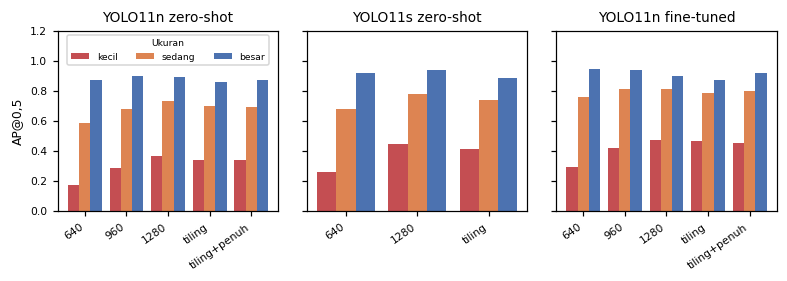

In [ ]:
# Grafik: AP@0,5 menurut ukuran untuk setiap (model, konfigurasi)
fig, ax = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True)
warna = {'kecil': '#c44e52', 'sedang': '#dd8452', 'besar': '#4c72b0'}
for a, nm in zip(ax, MODEL):
    sub = HASIL_UTAMA[HASIL_UTAMA['Model'] == nm].reset_index(drop=True)
    x = np.arange(len(sub)); lebar = 0.27
    for j, u in enumerate(['kecil', 'sedang', 'besar']):
        a.bar(x + (j - 1) * lebar, sub[f'AP50_{u}'], lebar, color=warna[u], label=u)
    a.set_xticks(x); a.set_xticklabels(sub['Konfigurasi'], rotation=35, ha='right'); a.set_title(nm)
ax[0].set_ylabel('AP@0,5'); ax[0].set_ylim(0, 1.2); ax[0].legend(title='Ukuran', loc='upper center', ncol=3, fontsize=6, title_fontsize=6)
plt.tight_layout(); plt.savefig(os.path.join(HASIL, 'g4_ap_ukuran.png'), dpi=220, bbox_inches='tight'); plt.show()

## 10. Rincian menurut kepadatan citra

Klaim paper berkaitan dengan objek kecil **yang berkelompok**. Untuk memisahkan pengaruh ukuran dari pengaruh kepadatan, citra uji dibagi menjadi tiga kelompok berdasarkan tersil jumlah objek valid per citra (jarang, sedang, padat). AP@0,5 untuk objek kecil dihitung terpisah pada tiap kelompok.

Batas tersil: jarang <= 48 objek, sedang <= 83 objek, padat > 83 objek
{'jarang': 184, 'sedang': 181, 'padat': 183} (jumlah citra per kelompok)


AP50 kecil | jarang  AP50 kecil | sedang  \
Model              Konfigurasi                                              
YOLO11n zero-shot  640                         0.209                0.181   
                   960                         0.340                0.300   
                   1280                        0.407                0.374   
                   tiling                      0.364                0.343   
                   tiling+penuh                0.360                0.340   
YOLO11s zero-shot  640                         0.312                0.270   
                   1280                        0.509                0.466   
                   tiling                      0.452                0.414   
YOLO11n fine-tuned 640                         0.338                0.315   
                   960                         0.452                0.436   
                   1280                        0.496                0.479   
                   tiling                      0.467                0.460   
                   tiling+penuh                0.469                0.451   

                                 AP50 kecil | padat  
Model              Konfigurasi                       
YOLO11n zero-shot  640                        0.164  
                   960                        0.279  
                   1280                       0.353  
                   tiling                     0.342  
                   tiling+penuh               0.337  
YOLO11s zero-shot  640                        0.243  
                   1280                       0.437  
                   tiling                     0.411  
YOLO11n fine-tuned 640                        0.270  
                   960                        0.398  
                   1280                       0.462  
                   tiling                     0.462  
                   tiling+penuh               0.447

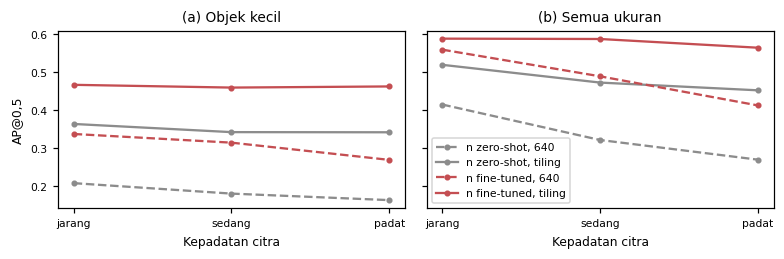

In [ ]:
n_obj = np.array([len(r['boxes']) for r in REK_VAL]); ids = np.array([r['id'] for r in REK_VAL])
q1, q2 = np.quantile(n_obj, [1 / 3, 2 / 3])
KELOMPOK = {'jarang': ids[n_obj <= q1], 'sedang': ids[(n_obj > q1) & (n_obj <= q2)], 'padat': ids[n_obj > q2]}
print(f'Batas tersil: jarang <= {q1:.0f} objek, sedang <= {q2:.0f} objek, padat > {q2:.0f} objek')
print({k: len(v) for k, v in KELOMPOK.items()}, '(jumlah citra per kelompok)')

baris = []
for (nm, kf), det in DETEKSI.items():
    r_ = {'Model': nm, 'Konfigurasi': kf}
    for g, ig in KELOMPOK.items():
        h = evaluasi_coco(GT_AGNOSTIK, det, img_ids=ig)
        r_[f'AP50 kecil | {g}'] = h['AP50_kecil']
        r_[f'AP50 semua | {g}'] = h['AP50_semua']
    baris.append(r_)
TABEL_KEPADATAN = pd.DataFrame(baris)
display(TABEL_KEPADATAN[['Model', 'Konfigurasi'] + [f'AP50 kecil | {g}' for g in KELOMPOK]].round(3).set_index(['Model', 'Konfigurasi']))

fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.4), sharey=True)
gaya = {('YOLO11n zero-shot', '640'): ('#8c8c8c', '--', 'n zero-shot, 640'), ('YOLO11n zero-shot', 'tiling'): ('#8c8c8c', '-', 'n zero-shot, tiling'),
        ('YOLO11n fine-tuned', '640'): ('#c44e52', '--', 'n fine-tuned, 640'), ('YOLO11n fine-tuned', 'tiling'): ('#c44e52', '-', 'n fine-tuned, tiling')}
for a, ukr in zip(ax, ['kecil', 'semua']):
    for (nm, kf), (wr, ls, lab) in gaya.items():
        brs = TABEL_KEPADATAN[(TABEL_KEPADATAN['Model'] == nm) & (TABEL_KEPADATAN['Konfigurasi'] == kf)].iloc[0]
        a.plot(list(KELOMPOK), [brs[f'AP50 {ukr} | {g}'] for g in KELOMPOK], color=wr, ls=ls, marker='o', ms=3, label=lab)
    a.set_xlabel('Kepadatan citra'); a.set_title('(a) Objek kecil' if ukr == 'kecil' else '(b) Semua ukuran')
ax[0].set_ylabel('AP@0,5'); ax[1].legend(loc='best')
plt.tight_layout(); plt.savefig(os.path.join(HASIL, 'g5_kepadatan.png'), dpi=220, bbox_inches='tight'); plt.show()

## 11. mAP per kelas (10 kelas) untuk model *fine-tuned*

Mode sadar kelas memberi mAP@0,5 dan mAP@0,5:0,95 standar (rerata atas sepuluh kelas VisDrone). Mode ini hanya berlaku bagi model *fine-tuned*, karena model COCO tidak mengenal kelas VisDrone seperti *people* dan *tricycle*.

In [ ]:
baris = []
for kf in MODEL['YOLO11n fine-tuned']['konfig']:
    h = evaluasi_coco(GT_KELAS, DETEKSI[('YOLO11n fine-tuned', kf)], sadar_kelas=True)
    baris.append({'Konfigurasi': kf, **{f'mAP50_{n}': h[f'AP50_{n}'] for n in UKURAN}, **{f'mAP50:95_{n}': h[f'AP50:95_{n}'] for n in UKURAN}})
TABEL_MAP10 = pd.DataFrame(baris).set_index('Konfigurasi')
display(TABEL_MAP10.round(3))

,mAP50_semua,mAP50_kecil,mAP50_sedang,mAP50_besar,mAP50:95_semua,mAP50:95_kecil,mAP50:95_sedang,mAP50:95_besar
Konfigurasi,,,,,,,,
640,0.132,0.072,0.212,0.293,0.075,0.029,0.121,0.210
960,0.168,0.112,0.244,0.267,0.096,0.051,0.146,0.201
1280,0.176,0.135,0.244,0.200,0.099,0.062,0.149,0.134
tiling,0.169,0.137,0.229,0.157,0.091,0.062,0.133,0.105
tiling+penuh,0.171,0.132,0.240,0.242,0.093,0.060,0.139,0.169


## 12. Analisis kasus gagal

Sel berikut memilih satu citra padat (persentil ke-90 jumlah objek) dan menampilkan sebuah potongan 640×480 piksel yang paling banyak memuat objek yang terlewat oleh model *fine-tuned* pada masukan 640. Panel kiri menunjukkan GT, panel tengah hasil masukan 640, dan panel kanan hasil *tiling*. Kotak hijau adalah deteksi yang benar (IoU ≥ 0,5 dengan GT), kuning adalah *false positive*, dan merah adalah GT yang terlewat. Hanya deteksi berskor ≥ 0,25 yang ditampilkan.

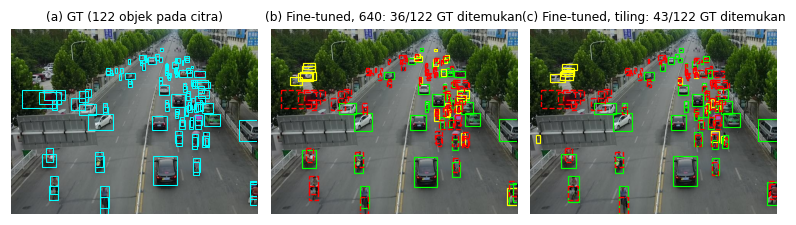

Citra: 0000155_00401_d_0000001 | ukuran: 960 x 540 | potongan mulai di (0, 40)
Recall objek (skor >= 0,25, IoU >= 0,5): 640 = 0.295 | tiling = 0.352
Deteksi benar / salah: 640 = 36/24 | tiling = 43/18


In [ ]:
def cocok_greedy(det_xyxy, skor, gt_xyxy, iou_min=0.5):
    """Mengembalikan (mask TP untuk deteksi, mask GT yang tertemu). Pencocokan greedy menurut skor."""
    tp = np.zeros(len(det_xyxy), bool); ditemu = np.zeros(len(gt_xyxy), bool)
    if len(det_xyxy) == 0 or len(gt_xyxy) == 0:
        return tp, ditemu
    a = det_xyxy; b = gt_xyxy
    ix1 = np.maximum(a[:, None, 0], b[None, :, 0]); iy1 = np.maximum(a[:, None, 1], b[None, :, 1])
    ix2 = np.minimum(a[:, None, 2], b[None, :, 2]); iy2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    luas_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); luas_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    iou = inter / (luas_a[:, None] + luas_b[None, :] - inter + 1e-9)
    for i in np.argsort(-skor):
        j = np.argmax(np.where(ditemu, -1, iou[i]))
        if iou[i, j] >= iou_min and not ditemu[j]:
            tp[i] = True; ditemu[j] = True
    return tp, ditemu

def deteksi_citra(det, id_citra, skor_min=0.25):
    d = det[(det[:, 0] == id_citra) & (det[:, 2] >= skor_min)]
    return d[:, 3:7], d[:, 2]

# Citra padat pada persentil ke-90 (deterministik)
urut_padat = np.argsort(n_obj)
id_pilih = int(ids[urut_padat[int(0.9 * (len(urut_padat) - 1))]])
rk = REK_VAL[id_pilih]
b640, s640 = deteksi_citra(DETEKSI[('YOLO11n fine-tuned', '640')], id_pilih)
btil, stil = deteksi_citra(DETEKSI[('YOLO11n fine-tuned', 'tiling')], id_pilih)
tp640, tem640 = cocok_greedy(b640, s640, rk['boxes']); tptil, temtil = cocok_greedy(btil, stil, rk['boxes'])

# Potongan 640x480 dengan jumlah GT terlewat (konfigurasi 640) terbanyak
pusat = np.c_[(rk['boxes'][:, 0] + rk['boxes'][:, 2]) / 2, (rk['boxes'][:, 1] + rk['boxes'][:, 3]) / 2]
terlewat = pusat[~tem640]
terbaik, kotak_potong = -1, (0, 0)
for x0 in range(0, max(rk['W'] - 640, 0) + 1, 40):
    for y0 in range(0, max(rk['H'] - 480, 0) + 1, 40):
        n = ((terlewat[:, 0] >= x0) & (terlewat[:, 0] < x0 + 640) & (terlewat[:, 1] >= y0) & (terlewat[:, 1] < y0 + 480)).sum() if len(terlewat) else 0
        if n > terbaik:
            terbaik, kotak_potong = n, (x0, y0)
x0, y0 = kotak_potong

def gambar_panel(a, judul, det, tp, gt, tem):
    a.imshow(Image.open(rk['path']).convert('RGB')); a.set_xlim(x0, x0 + 640); a.set_ylim(y0 + 480, y0); a.axis('off')
    if det is None:
        for b in gt:
            a.add_patch(patches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='cyan', lw=0.7))
    else:
        for b, ok in zip(det, tp):
            a.add_patch(patches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='lime' if ok else 'yellow', lw=0.8))
        for b, ok in zip(gt, tem):
            if not ok:
                a.add_patch(patches.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec='red', lw=0.9, ls='--'))
    a.set_title(judul, fontsize=8)

fig, ax = plt.subplots(1, 3, figsize=(7.2, 2.4))
gambar_panel(ax[0], f'(a) GT ({len(rk["boxes"])} objek pada citra)', None, None, rk['boxes'], None)
gambar_panel(ax[1], f'(b) Fine-tuned, 640: {int(tem640.sum())}/{len(rk["boxes"])} GT ditemukan', b640, tp640, rk['boxes'], tem640)
gambar_panel(ax[2], f'(c) Fine-tuned, tiling: {int(temtil.sum())}/{len(rk["boxes"])} GT ditemukan', btil, tptil, rk['boxes'], temtil)
plt.tight_layout(); plt.savefig(os.path.join(HASIL, 'g6_kasus_gagal.png'), dpi=250, bbox_inches='tight'); plt.show()
print('Citra:', rk['nama'], '| ukuran:', rk['W'], 'x', rk['H'], '| potongan mulai di', kotak_potong)
print(f'Recall objek (skor >= 0,25, IoU >= 0,5): 640 = {tem640.mean():.3f} | tiling = {temtil.mean():.3f}')
print(f'Deteksi benar / salah: 640 = {int(tp640.sum())}/{int((~tp640).sum())} | tiling = {int(tptil.sum())}/{int((~tptil).sum())}')

In [ ]:
# Kasus gagal tambahan: objek yang terlewat menurut ukuran dan kelas (model fine-tuned, 640 vs tiling, skor >= 0,25)
def rekap_terlewat(nama_konfig):
    det = DETEKSI[('YOLO11n fine-tuned', nama_konfig)]
    tot = np.zeros(10); dit = np.zeros(10); tot_u = np.zeros(3); dit_u = np.zeros(3)
    for r in REK_VAL:
        if len(r['boxes']) == 0:
            continue
        b, s = deteksi_citra(det, r['id'])
        _, tem = cocok_greedy(b, s, r['boxes'])
        luas = (r['boxes'][:, 2] - r['boxes'][:, 0]) * (r['boxes'][:, 3] - r['boxes'][:, 1])
        uk = np.where(luas < 32 ** 2, 0, np.where(luas < 96 ** 2, 1, 2))
        for k in range(10):
            tot[k] += (r['cls'] == k).sum(); dit[k] += tem[r['cls'] == k].sum()
        for u in range(3):
            tot_u[u] += (uk == u).sum(); dit_u[u] += tem[uk == u].sum()
    return dit / np.maximum(tot, 1), dit_u / np.maximum(tot_u, 1)

rek640_k, rek640_u = rekap_terlewat('640'); rektil_k, rektil_u = rekap_terlewat('tiling')
tabel_recall_ukuran = pd.DataFrame({'640': rek640_u, 'tiling': rektil_u}, index=['kecil', 'sedang', 'besar'])
tabel_recall_kelas = pd.DataFrame({'640': rek640_k, 'tiling': rektil_k}, index=KELAS)
print('Recall objek pada skor >= 0,25 (IoU >= 0,5), model fine-tuned')
display(tabel_recall_ukuran.round(3).T)
display(tabel_recall_kelas.round(3).T)

Recall objek pada skor >= 0,25 (IoU >= 0,5), model fine-tuned


,kecil,sedang,besar
640,0.217,0.68,0.90
tiling,0.404,0.74,0.85


,pedestrian,people,bicycle,car,van,truck,tricycle,awning-tricycle,bus,motor
640,0.185,0.113,0.063,0.652,0.586,0.384,0.244,0.314,0.406,0.172
tiling,0.426,0.207,0.127,0.780,0.704,0.455,0.295,0.365,0.462,0.318


## 13. Ringkasan dan penyimpanan hasil

Sel berikut menyimpan seluruh tabel utama ke berkas CSV dan JSON agar angka pada laporan dapat ditelusuri ke keluaran notebook ini.

In [ ]:
HASIL_UTAMA.to_csv(os.path.join(HASIL, 'hasil_utama.csv'), index=False)
TABEL_KEPADATAN.to_csv(os.path.join(HASIL, 'hasil_kepadatan.csv'), index=False)
TABEL_MAP10.to_csv(os.path.join(HASIL, 'hasil_map10.csv'))
tabel_grid.to_csv(os.path.join(HASIL, 'hasil_grid.csv'))
tabel_data.to_csv(os.path.join(HASIL, 'statistik_data.csv'))
tabel_resolusi.to_csv(os.path.join(HASIL, 'resolusi_efektif.csv'))
tabel_iou.to_csv(os.path.join(HASIL, 'sensitivitas_iou.csv'))
tabel_recall_ukuran.to_csv(os.path.join(HASIL, 'recall_ukuran.csv')); tabel_recall_kelas.to_csv(os.path.join(HASIL, 'recall_kelas.csv'))

def ambil(nm, kf, kolom):
    return float(HASIL_UTAMA[(HASIL_UTAMA['Model'] == nm) & (HASIL_UTAMA['Konfigurasi'] == kf)][kolom].iloc[0])

ringkasan = {
    'profil': PROFIL, 'seed': SEED, 'perangkat': 'GPU' if DEVICE != 'cpu' else 'CPU',
    'n_val': len(REK_VAL), 'n_latih': len(REK_LATIH), 'n_hold': len(REK_HOLD), 'epoch': KONFIG['epoch'],
    'kehilangan_grid_pct': {int(s): float(v) for s, v in tabel_grid['Kehilangan (%)'].items()},
    'ft_640_ap50_kecil': ambil('YOLO11n fine-tuned', '640', 'AP50_kecil'),
    'ft_640_ap50_besar': ambil('YOLO11n fine-tuned', '640', 'AP50_besar'),
    'ft_tiling_ap50_kecil': ambil('YOLO11n fine-tuned', 'tiling', 'AP50_kecil'),
    'zs_640_ap50_kecil': ambil('YOLO11n zero-shot', '640', 'AP50_kecil'),
    'zs_640_ap50_besar': ambil('YOLO11n zero-shot', '640', 'AP50_besar'),
}
json.dump(ringkasan, open(os.path.join(HASIL, 'ringkasan.json'), 'w'), indent=2)
print(json.dumps(ringkasan, indent=2))
print('Berkas hasil:', sorted(os.listdir(HASIL)))

{
  "profil": "ringan",
  "seed": 42,
  "perangkat": "GPU",
  "n_val": 548,
  "n_latih": 1000,
  "n_hold": 50,
  "epoch": 12,
  "kehilangan_grid_pct": {
    "7": 74.04989808818596,
    "13": 54.98593874970974,
    "20": 40.25387651900204,
    "40": 20.37720271420831,
    "80": 7.7556180500012895,
    "160": 1.9582548569364588
  },
  "ft_640_ap50_kecil": 0.28974298186291614,
  "ft_640_ap50_besar": 0.9473143703658817,
  "ft_tiling_ap50_kecil": 0.4619927928836908,
  "zs_640_ap50_kecil": 0.17054284471726114,
  "zs_640_ap50_besar": 0.8707262475512492
}
Berkas hasil: ['cache', 'g1_statistik.png', 'g2_grid.png', 'g3_pelatihan.png', 'g4_ap_ukuran.png', 'g5_kepadatan.png', 'g6_kasus_gagal.png', 'hasil_grid.csv', 'hasil_kepadatan.csv', 'hasil_map10.csv', 'hasil_utama.csv', 'recall_kelas.csv', 'recall_ukuran.csv', 'resolusi_efektif.csv', 'ringkasan.json', 'runs', 'sensitivitas_iou.csv', 'statistik_data.csv']


### Catatan keterbatasan

1. **Pelatihan singkat.** Model *fine-tuned* hanya dilatih pada subset kecil selama beberapa epoch, sehingga tidak konvergen. Angka mutlaknya tidak mewakili kemampuan penuh YOLO11 pada VisDrone.
2. **Ketidakcocokan skala.** Model *fine-tuned* dilatih pada masukan 640 piksel (citra diperkecil sekitar 0,47×), sedangkan *tiling* dan masukan 960 atau 1280 menyajikan objek dalam skala lebih besar. Ketidakcocokan ini dapat menekan manfaat intervensi dan perlu dipisahkan pada penelitian lanjutan dengan pelatihan pada skala yang sama.
3. **Model zero-shot dan kelas.** Pengujian *zero-shot* memakai mode agnostik kelas karena kelas COCO tidak identik dengan kelas VisDrone. Hasil ini tidak sebanding dengan mAP sadar kelas.
4. **Satu seed dan satu jalankan.** Tidak ada pengulangan dengan seed berbeda, sehingga selisih kecil antarkonfigurasi tidak dilengkapi interval kepercayaan.
5. **Penyederhanaan tiling.** Penggabungan irisan memakai NMS biasa dan bukan SAHI penuh, sehingga objek yang terpotong tepi irisan dapat menghasilkan *false positive* parsial.
6. **Set uji.** Seluruh VisDrone-DET *val* dipakai sebagai set uji, dan pemilihan *checkpoint* memakai citra *hold-out* dari *train*.